# Эксперимент 12: FluentNet-style (waveform + mel)

**Статья:** FluentNet: End-to-End Detection of Speech Disfluency with Deep Learning (FluentNet: сквозная детекция дисфлюенций речи с помощью глубокого обучения) 2020

**Ссылка:** [https://arxiv.org/abs/2009.11394](https://arxiv.org/abs/2009.11394)

**Краткое описание модели:** Двухветочная архитектура (waveform + mel), объединение признаков и финальная классификация.

**Содержание статьи:** FluentNet демонстрирует end-to-end обнаружение дисфлюенций и устойчивость к различным речевым паттернам. Ключевая идея — сочетать комплементарные представления сигнала в одной сети. Эксперимент использует этот архитектурный принцип для задачи дефектов речи.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
import torch
from torch.utils.data import DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и датасет (waveform + mel)

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

SR = config.TARGET_SR
MAX_SEC = config.MAX_DURATION_SEC
MAX_LEN = int(SR * MAX_SEC)
N_MELS = config.N_MELS
MAX_FRAMES = 320

def load_waveform(path):
    y, _ = data_utils.load_audio(path, sr=SR, max_sec=MAX_SEC)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode="constant", constant_values=0)
    else:
        y = y[:MAX_LEN]
    return y.astype(np.float32)

def load_mel(path):
    mel = data_utils.extract_mel_spectrogram(path, n_mels=N_MELS, max_frames=MAX_FRAMES, log=True)
    return mel

class FluentNetDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, letters):
        self.paths = paths
        self.labels = labels
        self.letters = letters
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        wav = load_waveform(self.paths[i])
        mel = load_mel(self.paths[i])
        let = torch.from_numpy(self.letters[i].astype(np.float32))
        return torch.from_numpy(wav), torch.from_numpy(mel).unsqueeze(0), let, self.labels[i]

train_ds = FluentNetDataset(paths_train, y_train, letters_train)
val_ds   = FluentNetDataset(paths_val, y_val, letters_val)
test_ds  = FluentNetDataset(paths_test, y_test, letters_test)
print(f"Waveform: {MAX_LEN} сэмплов ({MAX_SEC} с), mel: (1, {N_MELS}, {MAX_FRAMES})")

Train: 1942, Val: 417, Test: 417
Waveform: 160000 сэмплов (10.0 с), mel: (1, 80, 320)


## 2. DataLoader и модель

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [4]:
model = get_model(
    waveform_len=MAX_LEN,
    n_mels=N_MELS,
    n_frames=MAX_FRAMES,
    num_classes=2,
    n_letters=n_letters,
    branch_dim=128,
    dropout=0.3,
).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params}")

Параметров: 160626


## 3. Обучение

In [5]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [6]:
def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for wav, mel, letters, y in loader:
            wav, mel, letters, y = wav.to(device), mel.to(device), letters.to(device), y.to(device)
            logits = model(wav, mel, letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for wav, mel, letters, y in train_loader:
        wav, mel, letters, y = wav.to(device), mel.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(wav, mel, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
train_time_sec = time.perf_counter() - t0
print(f"Обучение заняло {train_time_sec:.1f} с.")

Epoch 1/50  train_loss=0.6505  val_f1_macro=0.6456
Epoch 2/50  train_loss=0.6373  val_f1_macro=0.6586
Epoch 3/50  train_loss=0.6395  val_f1_macro=0.6431
Epoch 4/50  train_loss=0.6286  val_f1_macro=0.6582
Epoch 5/50  train_loss=0.6310  val_f1_macro=0.2795
Epoch 6/50  train_loss=0.6175  val_f1_macro=0.6737
Epoch 7/50  train_loss=0.6178  val_f1_macro=0.7096
Epoch 8/50  train_loss=0.6158  val_f1_macro=0.2642
Epoch 9/50  train_loss=0.6056  val_f1_macro=0.6785
Epoch 10/50  train_loss=0.6149  val_f1_macro=0.2930
Epoch 11/50  train_loss=0.6125  val_f1_macro=0.2446
Epoch 12/50  train_loss=0.6132  val_f1_macro=0.7180
Epoch 13/50  train_loss=0.5940  val_f1_macro=0.6921
Epoch 14/50  train_loss=0.5974  val_f1_macro=0.6857
Epoch 15/50  train_loss=0.5914  val_f1_macro=0.5072
Epoch 16/50  train_loss=0.6016  val_f1_macro=0.6235
Epoch 17/50  train_loss=0.5861  val_f1_macro=0.6827
Epoch 18/50  train_loss=0.5914  val_f1_macro=0.4441
Epoch 19/50  train_loss=0.5829  val_f1_macro=0.3719
Epoch 20/50  train_lo

## 4. Оценка на тесте и метрики

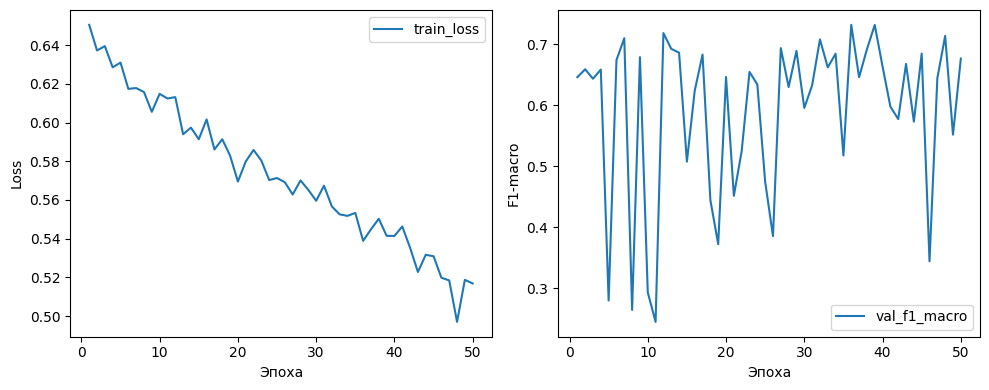

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, N_EPOCHS + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
model.eval()
all_logits = []
with torch.no_grad():
    for wav, mel, letters, _ in test_loader:
        wav, mel, letters = wav.to(device), mel.to(device), letters.to(device)
        all_logits.append(model(wav, mel, letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.84      0.70      0.76       282
         bad       0.53      0.71      0.61       135

    accuracy                           0.71       417
   macro avg       0.68      0.71      0.69       417
weighted avg       0.74      0.71      0.71       417

Accuracy: 0.7050
F1 macro: 0.6863
F1 (bad): 0.6095
ROC-AUC:  0.7849

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.705036,0.686265,0.609524,0.784896,0.533333,0.711111


## 5. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_12_fluentnet",
    experiment_name="FluentNet-style (waveform + mel)",
    model="FluentNetClassifier",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="two-branch 1D CNN + 2D CNN, 10s, branch_dim=128",
    num_params=n_params,
    train_time_sec=train_time_sec,
)